In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_pure_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [3]:
use_gpu=True                                                                                                                                       
dt = 10
T = 23/12 #NOTE: changed!

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
m1 = 3.54e6
m2 = 8.01e1
a = 0.950
p0 = 7.3890
e0 = 0.3160
xI0 = 1.0000
dist = 4.858
qS = 2.0420
phiS = 5.7873
qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 2.4044
Phi_theta0 = 0.2850
Phi_r0 = 0.9743                                                                                                                                                                                                                                                                                                                               
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [4]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [5]:
# n-indexed mode selection parameters
n_vals = np.arange(-20,20)  
ell = 2  # quadrupole only

In [6]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

# no noise check

In [7]:


loglike_obj = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 12097.290742692478 seconds
Selected modes (l,m,n): [[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)], [(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)], [(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)], [(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)], [(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)], [(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)], [(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)], [(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)], [(2, 0, -12), (2, 1, -12), (2, 2, -12), (2, -1, -12), (2, -2, -12)], [(2, 0, -11), (2, 1, -11), (2, 2, -11), (2, -1, -11), (2, -2, -11)], [(2, 0, -10), (2, 1, -10), (2, 2, -10), (2, -1, -10), (2, -2, -10)], [(2, 0, -9), (2, 1, -9), (2, 2, -9), (2, -1, -9), (2, -2, -9)], [(2, 0, -8), (2, 1, -8), (2, 2, -8), (2, -1, -8), (2, -2, -8)], [(2, 0, -7), (2, 1, -7), (2, 2, -

In [8]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

rho_tot=122.207, rho_dom_M=81.3221, beta=0.00105716
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)]  0.000834942  7.82313e-08      6.96997e-07
[(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)]  0.000631183  2.54603e-07       3.9807e-07
[(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)] -3.56889e-06  8.17601e-07      1.92413e-11
[(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)]  -0.00144756  2.52665e-06      2.10274e-06
[(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)]  -0.00361744  7.55282e-06      1.31406e-05
[(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)]  -0.00627747  2.23105e-05      3.96872e-05
[(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)]  -0.00884613  6.53555e-05      7.94146e-05
[(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)]   -0.0100786  0.000189035      0.000105

In [9]:
params_secondary = [10**6.5490032, 10**1.90363256, 0.95000013, 7.3890003, 0.316, xI0, 
                dist,np.arccos(-0.47067891),5.79959081, qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [10]:
h_true = gwf.xp.array(waveform_response(
    m1, m2, a, p0, e0,
    xI0, dist,qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [11]:
maxld_pt1 = [[ 6.5490032 ,  1.90363256,  0.95000013,  7.3890003 ,  0.316     ,
       -0.47067891,  5.79959081 ]]

In [12]:
h_pt1 = gwf.xp.array(waveform_response(
    10**maxld_pt1[0][0], 10**maxld_pt1[0][1], maxld_pt1[0][2], maxld_pt1[0][3], maxld_pt1[0][4],
    xI0, dist, np.arccos(maxld_pt1[0][5]),maxld_pt1[0][6], qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [13]:
gwf.rhostat(h_true), gwf.rhostat(h_pt1)

(array(122.20657624), array(118.8140659))

In [14]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_true))/(gwf.rhostat(h_true)*gwf.rhostat(h_true))

array(1.)

In [15]:
gwf.inner(gwf.freq_wave(h_pt1), gwf.freq_wave(h_pt1))/(gwf.rhostat(h_pt1)*gwf.rhostat(h_pt1))

array(1.)

In [16]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_pt1))/(gwf.rhostat(h_true)*gwf.rhostat(h_pt1))

array(0.99895607)

In [17]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_pt1))/np.sqrt(gwf.inner(gwf.freq_wave(h_pt1), gwf.freq_wave(h_pt1)))

array(122.07900065)

In [18]:
np.sqrt(gwf.inner(gwf.freq_wave(h_pt1),gwf.freq_wave(h_pt1)))

array(118.8140659)

In [19]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_true))/np.sqrt(gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_true)))

array(122.20657624)

In [20]:
np.sqrt(gwf.inner(gwf.freq_wave(h_pt1), gwf.freq_wave(h_pt1)))

array(118.8140659)

In [21]:
loglike_obj(params_secondary)

rho_tot=118.814, rho_dom_M=79.2852, beta=0.00111691
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)]  0.000790309  8.34897e-08      6.24457e-07
[(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)]  0.000506704  2.71588e-07      2.56474e-07
[(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)] -0.000197463  8.71662e-07      3.93368e-08
[(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)]  -0.00167883  2.69295e-06      2.82751e-06
[(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)]  -0.00382366   8.0499e-06       1.4682e-05
[(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)]   -0.0063767  2.37766e-05      4.09661e-05
[(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)]  -0.00872666  6.96364e-05      7.73748e-05
[(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)]  -0.00972313  0.000201354      9.84954e

117.110595233511

In [23]:
delta_T = loglike_obj.delta_T

In [24]:
import numpy as np
from few.utils.geodesic import get_fundamental_frequencies

amp = loglike_obj.amp

_, p, e, x, _, _, _ = loglike_obj.traj(
    m1, m2, a, p0, e0, xI0,
    T=T, dt=delta_T, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
)
teuk_modes = amp(a, p, e, x)

def _get_viewing_angles(qS, phiS, qK, phiK):
    cqS, sqS = np.cos(qS), np.sin(qS)
    cphiS, sphiS = np.cos(phiS), np.sin(phiS)
    cqK, sqK = np.cos(qK), np.sin(qK)
    cphiK, sphiK = np.cos(phiK), np.sin(phiK)
    R = np.array([sqS*cphiS, sqS*sphiS, cqS])
    S = np.array([sqK*cphiK, sqK*sphiK, cqK])
    phi = -np.pi/2.0
    theta = np.arccos(-np.dot(R, S))
    return theta, phi

theta_view, phi_view = _get_viewing_angles(qS, phiS, qK, phiK)
ylms = loglike_obj.ylm_gen(amp.unique_l, amp.unique_m, theta_view, phi_view).copy()[amp.inverse_lm]

OmegaPhi, _, OmegaR = get_fundamental_frequencies(a, p, e, x)

l_arr_nm = amp.l_arr_no_mask.get() if hasattr(amp.l_arr_no_mask, 'get') else np.asarray(amp.l_arr_no_mask)
m_arr_nm = amp.m_arr_no_mask.get() if hasattr(amp.m_arr_no_mask, 'get') else np.asarray(amp.m_arr_no_mask)
n_arr_nm = amp.n_arr_no_mask.get() if hasattr(amp.n_arr_no_mask, 'get') else np.asarray(amp.n_arr_no_mask)

m0mask = amp.m_arr_no_mask != 0
m0mask_cpu = m0mask.get() if hasattr(m0mask, 'get') else m0mask

# frequencies for teuk_modes' own (positive-m / no_mask) columns
gw_freqs_pos = []
for idx in range(len(l_arr_nm)):
    mm = m_arr_nm[idx].get() if hasattr(m_arr_nm[idx], 'get') else m_arr_nm[idx]
    nn = n_arr_nm[idx].get() if hasattr(n_arr_nm[idx], 'get') else n_arr_nm[idx]
    gw_freqs_pos.append(mm * OmegaPhi + nn * OmegaR)

# mirrored -m frequencies for the m0mask-selected reconstructed columns (appended after, same order)
gw_freqs_neg = []
for idx in range(len(l_arr_nm)):
    if not m0mask_cpu[idx]:
        continue
    mm = m_arr_nm[idx].get() if hasattr(m_arr_nm[idx], 'get') else m_arr_nm[idx]
    nn = n_arr_nm[idx].get() if hasattr(n_arr_nm[idx], 'get') else n_arr_nm[idx]
    gw_freqs_neg.append(-mm * OmegaPhi + nn * OmegaR)

gw_frequencies_per_mode = gw_freqs_pos + gw_freqs_neg

total_power = gwf.calc_power(teuk_modes, ylms, m0mask, m1=m1, m2=m2, gw_freqs=gw_frequencies_per_mode)
total_power = total_power.get() if hasattr(total_power, 'get') else total_power

pos_labels = [(int(l_arr_nm[i]), int(m_arr_nm[i]), int(n_arr_nm[i])) for i in range(len(l_arr_nm))]
neg_labels = [(int(l_arr_nm[i]), -int(m_arr_nm[i]), int(n_arr_nm[i])) for i in range(len(l_arr_nm)) if m0mask_cpu[i]]
mode_labels = pos_labels + neg_labels

power_sum = float(np.sum(total_power))
per_n = {}
for (ll, mm, nn), pw in zip(mode_labels, total_power):
    if ll != 2:
        continue
    per_n[nn] = per_n.get(nn, 0.0) + float(pw)

print(f"{'n':>4} {'power %':>10}")
for n in sorted(per_n, key=lambda k: -per_n[k])[:15]:
    print(f"{n:>4} {100*per_n[n]/power_sum:>10.4f}")

   n    power %
   0    53.4234
   1    19.1166
  -1     6.9174
   2     3.7647
   3     0.6071
   4     0.0939
  -2     0.0303
   5     0.0130
   6     0.0017
   7     0.0002
  -3     0.0001
  -4     0.0000
   8     0.0000
  -5     0.0000
   9     0.0000


In [25]:
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [26]:
params_star

[3540000.0,
 80.1,
 0.95,
 7.389,
 0.316,
 1.0,
 4.858,
 2.042,
 5.7873,
 2.0657160741551595,
 1.7660320006905623,
 2.4044,
 0.285,
 0.9743]

# 2 yr with noise

In [35]:
from few.utils.constants import YRSID_SI
from few.utils.geodesic import get_separatrix

traj_gen = loglike_obj.traj   # the inspiral generator already built inside loglike_obj

T_cap = 10.0   # years -- generously longer than the 23mth observation, so plunge (if any) shows up
out = traj_gen(m1, m2, a, p0, e0, xI0, T=T_cap)
t, p, e, xI = out[0], out[1], out[2], out[3]   # (t, p, e, x, Phi_phi, Phi_theta, Phi_r, ...) -- check order if this errors

print(f"trajectory ran for {t[-1]/YRSID_SI:.6f} yr out of the requested {T_cap} yr cap")
print(f"final p = {p[-1]:.6f}, final e = {e[-1]:.6f}")
print(f"separatrix at final (a, e, x) = {get_separatrix(a, e[-1], xI[-1]):.6f}")

if t[-1] < (T_cap - 1e-3) * YRSID_SI:
    print(f"\n==> SYSTEM PLUNGES at t = {t[-1]/YRSID_SI:.6f} yr after p0={p0}")
else:
    print(f"\n==> does NOT plunge within {T_cap} yr -- still inspiraling")

# specifically: has it plunged by the actual observation duration T?
T_obs_sec = T * YRSID_SI   # T is your EMRI_C observation duration, 23/1
if t[-1] <= T_obs_sec:
    print(f"This means it plunges BEFORE the {T*12:.0f}mth observation ends "
          f"({t[-1]/YRSID_SI*12:.2f} months in).")
else:
    idx = np.searchsorted(t, T_obs_sec)
    print(f"Still inspiraling at the end of the {T*12:.0f}mth observation: "
          f"p(T)~{p[idx]:.6f}, margin from separatrix~{p[idx] - get_separatrix(a, e[idx], xI[idx]):.6f}")

trajectory ran for 1.944898 yr out of the requested 10.0 yr cap
final p = 1.980524, final e = 0.059208
separatrix at final (a, e, x) = 1.978524

==> SYSTEM PLUNGES at t = 1.944898 yr after p0=7.389
Still inspiraling at the end of the 23mth observation: p(T)~2.647889, margin from separatrix~0.668416


In [36]:
23/12

1.9166666666666667

In [37]:
gwf_2yr=GravWaveAnalysis(T=1.944898, dt=dt, use_gpu=True,tdi_gen=1)
waveform_response_2yr = build_waveform_response(T=1.944898, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    

loglike_2yr = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response_2yr,                                                                                                                                                                            
    gwf=gwf_2yr,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 12275.476471764061 seconds
Selected modes (l,m,n): [[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)], [(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)], [(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)], [(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)], [(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)], [(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)], [(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)], [(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)], [(2, 0, -12), (2, 1, -12), (2, 2, -12), (2, -1, -12), (2, -2, -12)], [(2, 0, -11), (2, 1, -11), (2, 2, -11), (2, -1, -11), (2, -2, -11)], [(2, 0, -10), (2, 1, -10), (2, 2, -10), (2, -1, -10), (2, -2, -10)], [(2, 0, -9), (2, 1, -9), (2, 2, -9), (2, -1, -9), (2, -2, -9)], [(2, 0, -8), (2, 1, -8), (2, 2, -8), (2, -1, -8), (2, -2, 

In [38]:
#loglike at true param
logl_2yr=loglike_2yr(params)
print(logl_2yr)

rho_tot=154.115, rho_dom_M=108.984, beta=0.000790158
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)]      1.13861  7.82332e-08          1.29644
[(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)]      2.90345  2.54607e-07          8.43003
[(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)]     -1.06776  8.17609e-07          1.14012
[(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)]      2.03806  2.52666e-06          4.15369
[(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)]     0.831266  7.55284e-06          0.69099
[(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)]     -1.91939  2.23105e-05          3.68414
[(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)]      1.53674  6.53556e-05          2.36137
[(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)]    -0.881156  0.000189035         0.77

In [39]:
#loglike at true param
logl_2yr=loglike_2yr(params_secondary)
print(logl_2yr)

rho_tot=149.958, rho_dom_M=106.416, beta=0.000836217
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)]      1.15291  8.34916e-08           1.3292
[(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)]      2.94625  2.71593e-07          8.68039
[(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)]     -1.07565   8.7167e-07          1.15703
[(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)]      1.96446  2.69296e-06          3.85908
[(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)]      0.83421  8.04992e-06         0.695894
[(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)]     -2.11229  2.37766e-05          4.46187
[(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)]      1.47159  6.96364e-05          2.16539
[(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)]    -0.985943  0.000201354         0.97

# check orthogonality

In [40]:
waveforms_per_group = []

# POSITIVE
groups = [
    [(2,-2,-1),(2,-1,-1),(2,0,-1),(2,1,-1),(2,2,-1)],   #0
    [(2,-2,0), (2,-1,0), (2,0,0), (2,1,0), (2,2,0)],    #1
    [(2,-2,1), (2,-1,1), (2,0,1), (2,1,1), (2,2,1)],    #2
    [(2,-2,2), (2,-1,2), (2,0,2), (2,1,2), (2,2,2)],    #3
    [(2,-2,3), (2,-1,3), (2,0,3), (2,1,3), (2,2,3)],    #4
    [(2,-2,4), (2,-1,4), (2,0,4), (2,1,4), (2,2,4)],    #5
    [(2,-2,5), (2,-1,5), (2,0,5), (2,1,5), (2,2,5)],    #6
    [(3,-3,-1),(3,-2,-1),(3,-1,-1),(3,0,-1),(3,1,-1),(3,2,-1),(3,3,-1)],  #7
    [(3,-3,0), (3,-2,0), (3,-1,0), (3,0,0), (3,1,0), (3,2,0), (3,3,0)],   #8
    [(3,-3,1), (3,-2,1), (3,-1,1), (3,0,1), (3,1,1), (3,2,1), (3,3,1)],   #9
    [(3,-3,2), (3,-2,2), (3,-1,2), (3,0,2), (3,1,2), (3,2,2), (3,3,2)],   #10
    [(3,-3,3), (3,-2,3), (3,-1,3), (3,0,3), (3,1,3), (3,2,3), (3,3,3)],   #11
    [(3,-3,4), (3,-2,4), (3,-1,4), (3,0,4), (3,1,4), (3,2,4), (3,3,4)],   #12
    [(3,-3,5), (3,-2,5), (3,-1,5), (3,0,5), (3,1,5), (3,2,5), (3,3,5)],   #13
]

#NEGATVIVE
# groups = [
#     [(2,-2,-5),(2,-1,-5),(2,0,-5),(2,1,-5),(2,2,-5)],   #0
#     [(2,-2,-4),(2,-1,-4),(2,0,-4),(2,1,-4),(2,2,-4)],   #1
#     [(2,-2,-3),(2,-1,-3),(2,0,-3),(2,1,-3),(2,2,-3)],   #2
#     [(2,-2,-2),(2,-1,-2),(2,0,-2),(2,1,-2),(2,2,-2)],   #3
#     [(2,-2,-1),(2,-1,-1),(2,0,-1),(2,1,-1),(2,2,-1)],   #4
#     [(2,-2,0), (2,-1,0), (2,0,0), (2,1,0), (2,2,0)],    #5
#     [(2,-2,1), (2,-1,1), (2,0,1), (2,1,1), (2,2,1)],    #6
#     [(3,-3,-5),(3,-2,-5),(3,-1,-5),(3,0,-5),(3,1,-5),(3,2,-5),(3,3,-5)],  #7
#     [(3,-3,-4),(3,-2,-4),(3,-1,-4),(3,0,-4),(3,1,-4),(3,2,-4),(3,3,-4)],  #8
#     [(3,-3,-3),(3,-2,-3),(3,-1,-3),(3,0,-3),(3,1,-3),(3,2,-3),(3,3,-3)],  #9
#     [(3,-3,-2),(3,-2,-2),(3,-1,-2),(3,0,-2),(3,1,-2),(3,2,-2),(3,3,-2)],  #10
#     [(3,-3,-1),(3,-2,-1),(3,-1,-1),(3,0,-1),(3,1,-1),(3,2,-1),(3,3,-1)],  #11
#     [(3,-3,0), (3,-2,0), (3,-1,0), (3,0,0), (3,1,0), (3,2,0), (3,3,0)],   #12
#     [(3,-3,1), (3,-2,1), (3,-1,1), (3,0,1), (3,1,1), (3,2,1), (3,3,1)],   #13
# ]
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
waveforms = [   
    cp.array(waveform_response(*params, T=T, dt=dt, mode_selection=g, include_minus_mkn=False))                                                                                    
    for g in groups                                                                                                                                                                
]

In [41]:
n = len(groups)                                                                                                                                                                    
overlap_matrix = np.zeros((n, n))
                                                                                                                                                                                    
for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])                                                                                                                                         
        overlap_matrix[i, j] = float(cp.real(gwf.overlap(hi_f, hj_f)))   

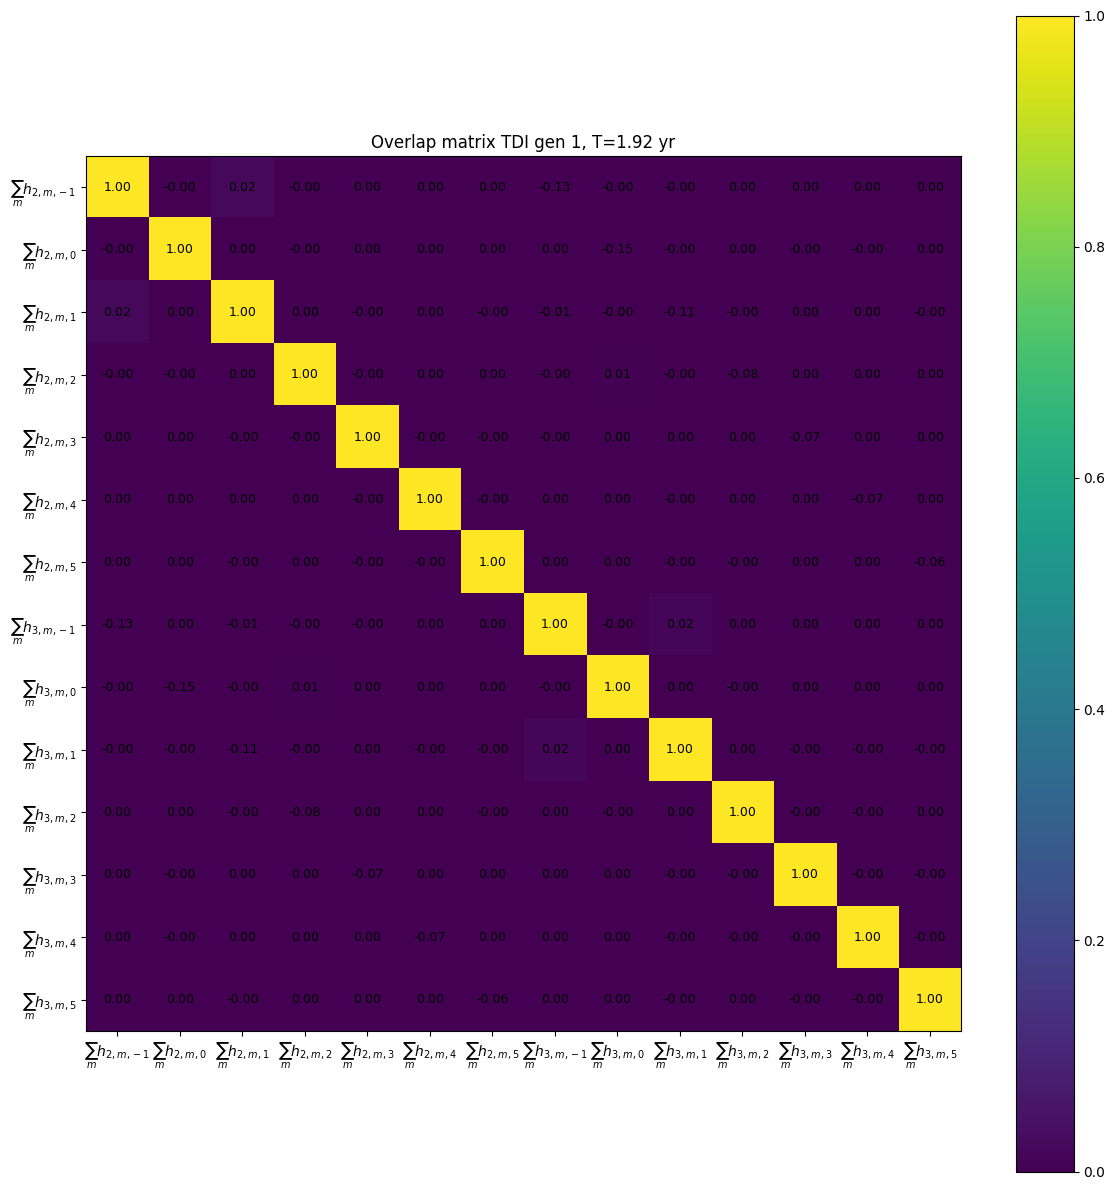

In [42]:
# Display as heatmap
# POSITIVE
labels = [
    r'$\sum_m h_{2,m,-1}$',
    r'$\sum_m h_{2,m,0}$',
    r'$\sum_m h_{2,m,1}$',
    r'$\sum_m h_{2,m,2}$',
    r'$\sum_m h_{2,m,3}$',
    r'$\sum_m h_{2,m,4}$',
    r'$\sum_m h_{2,m,5}$',
    r'$\sum_m h_{3,m,-1}$',
    r'$\sum_m h_{3,m,0}$',
    r'$\sum_m h_{3,m,1}$',
    r'$\sum_m h_{3,m,2}$',
    r'$\sum_m h_{3,m,3}$',
    r'$\sum_m h_{3,m,4}$',
    r'$\sum_m h_{3,m,5}$',
]
# labels = [
#     r'$\sum_m h_{2,m,-5}$',
#     r'$\sum_m h_{2,m,-4}$',
#     r'$\sum_m h_{2,m,-3}$',
#     r'$\sum_m h_{2,m,-2}$',
#     r'$\sum_m h_{2,m,-1}$',
#     r'$\sum_m h_{2,m,0}$',
#     r'$\sum_m h_{2,m,1}$',
#     r'$\sum_m h_{3,m,-5}$',
#     r'$\sum_m h_{3,m,-4}$',
#     r'$\sum_m h_{3,m,-3}$',
#     r'$\sum_m h_{3,m,-2}$',
#     r'$\sum_m h_{3,m,-1}$',
#     r'$\sum_m h_{3,m,0}$',
#     r'$\sum_m h_{3,m,1}$',
# ]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))                                                                                                                                             
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)                                                                                                                                
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_title('Overlap matrix TDI gen 1, T={:.2f} yr'.format(T))                                                                                                                                          
plt.colorbar(im, ax=ax)
for i in range(n):                                                                                                                                                                 
    for j in range(n):                                                                                                                                                             
        ax.text(j, i, f'{overlap_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()                                                                                                                                                                 
plt.show() 

In [43]:
overlap_matrix

array([[ 1.00000000e+00, -5.57817175e-05,  2.18044607e-02,
        -7.71593225e-06,  3.10563625e-07,  8.40975240e-07,
         1.16088666e-06, -1.30428595e-01, -8.74029213e-06,
        -3.43341016e-03,  1.29397774e-05,  1.90613346e-06,
         3.42051116e-07,  8.84383105e-07],
       [-5.57817175e-05,  1.00000000e+00,  5.94955828e-05,
        -1.18146996e-04,  8.59401980e-06,  1.39491702e-07,
         5.48863186e-07,  6.89929545e-05, -1.54367227e-01,
        -1.78149791e-05,  1.05744907e-04, -3.35728194e-07,
        -5.29803358e-08,  9.89118454e-07],
       [ 2.18044607e-02,  5.94955828e-05,  1.00000000e+00,
         1.60959969e-05, -1.30966400e-05,  1.67279814e-05,
        -2.11139176e-06, -1.19171883e-02, -6.95113389e-05,
        -1.06689668e-01, -7.94649711e-06,  3.42486382e-06,
         5.99921799e-07, -1.26630969e-06],
       [-7.71593225e-06, -1.18146996e-04,  1.60959969e-05,
         1.00000000e+00, -1.61539590e-06,  3.68683377e-06,
         2.41196566e-05, -1.17647699e-04,  6.

# conditionals 3 mth

In [ ]:
  import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 3/12
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [ ]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

In [ ]:
param_true

In [ ]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

In [ ]:
def get_separatrix(a, e0):
    from few.utils.geodesic import get_separatrix
    return get_separatrix(a, e0, 1.0)  # xI=1 (prograde)

In [ ]:
get_separatrix(0.335, 0.347)

In [ ]:
f_stats_tmX

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()